**1.Import Data**

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures


**2.Read CSV & Prepare Data**

In [33]:

df=pd.read_csv('Weight-Height Polynomial Dataset.csv')
x=df[['Weight']]
y=df['Height']

**3.Check correlation**

In [34]:

df.corr()

,Weight,Height
Weight,1.000000,0.963558
Height,0.963558,1.000000


In [35]:
xtrain, xtest, ytrain, ytest =train_test_split(x,y, test_size=0.8, random_state=42)

**4. Scatter Plot**

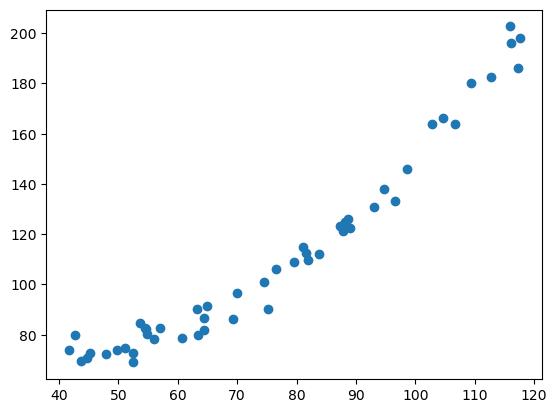

In [36]:
plt.scatter(df[['Weight']],df['Height'])

**5. Create Model & Train Model**

In [37]:
model=LinearRegression()
model.fit(xtrain,ytrain)

LinearRegression()

**6. Predict Output**

In [38]:

ypred=model.predict(xtrain)
error=ytrain-ypred

**7. Find Slope and Coefficient**

In [39]:
slope=model.coef_
intercept=model.intercept_

In [40]:
ypred_train=model.predict(xtrain)
score=r2_score(ytrain, ypred_train)

In [48]:
poly=PolynomialFeatures(degree=2)
updated_xtrain=poly.fit_transform(xtrain)
updated_xtest=poly.transform(xtest)

In [49]:
model=LinearRegression()
model.fit(updated_xtrain,ytrain)


LinearRegression()

In [50]:
updated_xtrain

array([[1.00000000e+00, 4.16467595e+01, 1.73445258e+03],
       [1.00000000e+00, 6.33715719e+01, 4.01595612e+03],
       [1.00000000e+00, 7.45556015e+01, 5.55853771e+03],
       [1.00000000e+00, 5.47883564e+01, 3.00176400e+03],
       [1.00000000e+00, 8.89482316e+01, 7.91178790e+03],
       [1.00000000e+00, 1.09294092e+02, 1.19451985e+04],
       [1.00000000e+00, 4.27510817e+01, 1.82765499e+03],
       [1.00000000e+00, 5.45459974e+01, 2.97526583e+03],
       [1.00000000e+00, 8.73931655e+01, 7.63756538e+03],
       [1.00000000e+00, 9.47386421e+01, 8.97541031e+03]])

In [51]:
ypred_train=model.predict(updated_xtrain)

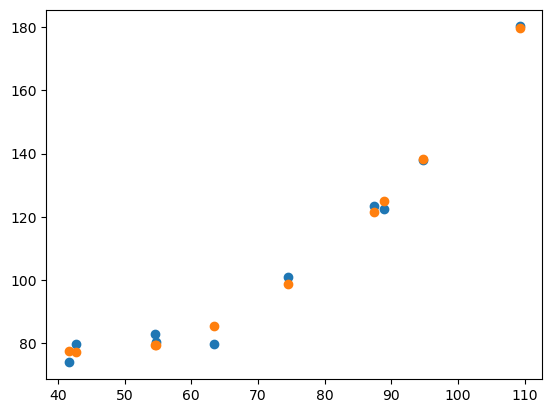

In [52]:
plt.scatter(updated_xtrain[:,1],ytrain)
plt.scatter(updated_xtrain[:,1],ypred_train)

In [53]:
train_score=r2_score(ytrain,ypred_train)
print(f"Train Score: {train_score}")


Train Score: 0.9924857441236121


In [54]:
ypred_test=model.predict(updated_xtest)
test_score=r2_score(ytest,ypred_test)
print(f"Test Score: {test_score}")


Test Score: 0.9773329363031369


**degree=1**

Train Score: 0.8934563138452002                         &        Test Score: 0.9089169981283863              


**degree=2**

Train Score: 0.9924857441236121                 &          Test Score: 0.9773329363031369  ( Hence degree 2 is best )


**degree=3**
 
Train Score: 0.9925847684004158              &              Test Score: 0.9752075169786864

**degree=4**
     
Train Score: 0.9927822619600151              &          Test Score: 0.9793105381233427      